In [16]:
import gc
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from scipy import stats
import s3_utils

In [29]:
log_keys = s3_utils.list_keys("outputs/gpt2-xl/winogender/fine_tuned/logs/")
prefix = s3_utils.s3_key("outputs/gpt2-xl/winogender/fine_tuned/logs/")

In [30]:
run_ids = [
    k[len(prefix):].replace(".json", "")
    for k in log_keys
    if k.endswith(".json") and "all_experiment" not in k
]
runs_metadata = []
for rid in run_ids:
    log = s3_utils.read_json(f"outputs/gpt2-xl/winogender/fine_tuned/logs/{rid}.json")
    runs_metadata.append({
        "run_id": rid,
        "loss_type": log.get("loss_type"),
        "experiment_type": log.get("experiment_type"),
        "percentile": log.get("percentile"),
        "active_pct": log.get("active_pct", 0.0),
        "learning_rate": log.get("learning_rate"),
        "dpo_beta": log.get("dpo_beta", np.nan),
        "ul_weight": log.get("ul_weight", np.nan),
        "best_val_loss": log.get("best_val_loss"),
        "best_epoch": log.get("best_epoch"),
        "total_epochs": log.get("total_epochs"),
        "epochs": log.get("epochs", []),
    })

runs_metadata_df = pd.DataFrame(runs_metadata)
print(f"Discovered {len(runs_metadata_df)} training runs.")
runs_metadata_df[["run_id", "loss_type", "experiment_type", "percentile", "learning_rate", "active_pct"]].head(20)

Discovered 152 training runs.


,run_id,loss_type,experiment_type,percentile,learning_rate,active_pct
0,wino_dpo_attn_0.5_beta0.3_lr1e-05,dpo,attn,0.5,0.000010,0.1501
1,wino_dpo_attn_0.5_beta0.3_lr1e-06,dpo,attn,0.5,0.000001,0.1501
2,wino_dpo_attn_0.5_beta0.3_lr5e-06,dpo,attn,0.5,0.000005,0.1501
3,wino_dpo_attn_0.5_beta0.5_lr1e-05,dpo,attn,0.5,0.000010,0.1501
4,wino_dpo_attn_0.5_beta0.5_lr1e-06,dpo,attn,0.5,0.000001,0.1501
5,wino_dpo_attn_0.5_beta0.5_lr5e-06,dpo,attn,0.5,0.000005,0.1501
6,wino_dpo_attn_0.8_beta0.3_lr1e-05,dpo,attn,0.8,0.000010,0.2502
7,wino_dpo_attn_0.8_beta0.3_lr1e-06,dpo,attn,0.8,0.000001,0.2502
8,wino_dpo_attn_0.8_beta0.3_lr5e-06,dpo,attn,0.8,0.000005,0.2502
9,wino_dpo_attn_0.8_beta0.5_lr1e-05,dpo,attn,0.8,0.000010,0.2502


In [31]:
def extract_pronoun_prefs(pronoun_df, sentence_role=None):
    """Extract last-layer accumulated prob per (ID, Gender) from Stage 1 data.

    Returns a DataFrame with columns: ID, P_male, P_female, P_neutral,
    preferred_gender, male_female_ratio.
    """
    df = pronoun_df.copy()
    if sentence_role is not None:
        df = df[df["Sentence_Role"] == sentence_role]

    max_layer = df["Layer"].max()
    last_tok = df.groupby(["ID", "Gender", "Layer"])["Token_Position"].idxmax()
    final = df.loc[last_tok]
    final = final[final["Layer"] == max_layer]

    pivot = final.pivot_table(
        index="ID", columns="Gender",
        values="Layer_Accumulated_Prob", aggfunc="first",
    ).fillna(0)

    result = pd.DataFrame({"ID": pivot.index})
    result["P_male"] = pivot.get("male", 0).values
    result["P_female"] = pivot.get("female", 0).values
    result["P_neutral"] = pivot.get("neutral", 0).values
    result["preferred_gender"] = pivot.idxmax(axis=1).values
    result["male_female_ratio"] = result["P_male"] / (result["P_female"] + 1e-30)
    return result.reset_index(drop=True)


def compute_run_metrics(prob_df, meta_df):
    """Compute adapted SS / BLS / ICAT metrics for Winogender.

    Returns (metrics_dict, bias_df).
    metrics_dict has: SS, BLS_r, BLS_score, ICAT.
    bias_df has per-occupation detail for downstream analysis (DLA plots).
    """
    occ = extract_pronoun_prefs(prob_df, "occupation")
    merged = occ.merge(meta_df[["ID", "occupation", "bls_pct_female"]], on="ID", how="left")
    merged["stereo_gender"] = merged["bls_pct_female"].apply(
        lambda x: "female" if x > 50 else "male"
    )
    merged["anti_gender"] = merged["stereo_gender"].apply(
        lambda x: "female" if x == "male" else "male"
    )
    merged["P_stereo"] = np.where(
        merged["stereo_gender"] == "male", merged["P_male"], merged["P_female"]
    )
    merged["P_anti"] = np.where(
        merged["anti_gender"] == "male", merged["P_male"], merged["P_female"]
    )

    n_stereo = (merged["P_stereo"] > merged["P_anti"]).sum()
    n_anti = (merged["P_anti"] > merged["P_stereo"]).sum()
    denom = n_stereo + n_anti
    ss = (n_stereo / denom * 100) if denom > 0 else 50.0

    bls_r, _ = stats.pearsonr(merged["bls_pct_female"], merged["P_stereo"])
    bls_score = (1 - abs(bls_r)) * 100

    icat = bls_score * (min(ss, 100 - ss) / 50.0)

    merged["diff_stereo"] = merged["P_stereo"] - merged["P_anti"]

    metrics = {"SS": ss, "BLS_r": bls_r, "BLS_score": bls_score, "ICAT": icat}
    return metrics, merged


def generate_dla_plot(occ_name, impact_df, pronoun_occ_df, bias_row, save_prefix=""):
    """3-panel DLA impact plot for a single occupation (occupation sentence only).

    Uses Gender column (male/female/neutral) instead of StereoSet Type column.
    """
    pair_id = bias_row["ID"]
    sub_impact = impact_df[impact_df["ID"] == pair_id].copy()
    sub_probs = pronoun_occ_df[pronoun_occ_df["ID"] == pair_id].copy()

    if sub_impact.empty:
        print(f"  No impact data for {occ_name}, skipping.")
        return

    gender_map = {"male": "Male", "female": "Female", "neutral": "Neutral"}
    sub_impact["Gender"] = sub_impact["Gender"].map(gender_map)
    sub_probs["Gender"] = sub_probs["Gender"].map(gender_map)

    stereo_label = "Male" if bias_row["stereo_gender"] == "male" else "Female"
    anti_label = "Female" if stereo_label == "Male" else "Male"

    mlp_df = sub_impact[sub_impact["Component"] == "MLP"]
    mlp_summary = mlp_df.groupby(["Layer", "Gender"])["Accumulated_Impact"].mean().reset_index()

    prob_summary = sub_probs.groupby(["Layer", "Gender"])["Layer_Accumulated_Prob"].mean().reset_index()
    prob_pivot = prob_summary.pivot(index="Layer", columns="Gender", values="Layer_Accumulated_Prob").fillna(0)
    margin_df = pd.DataFrame({"Layer": prob_pivot.index})
    margin_df["Margin"] = prob_pivot.get(stereo_label, 0).values - prob_pivot.get(anti_label, 0).values

    head_df = sub_impact[sub_impact["Component"].str.startswith("Head")].copy()
    head_df["Head_ID"] = head_df["Component"].str.replace("Head_", "").astype(int)
    heatmap_data = head_df[head_df["Gender"] == stereo_label]
    head_matrix = heatmap_data.groupby(["Head_ID", "Layer"])["Accumulated_Impact"].mean().unstack()

    head_sum = head_df.groupby(["Layer", "Gender"])["Accumulated_Impact"].sum().reset_index()

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.9], hspace=0.3, wspace=0.25)
    ax_mlp = fig.add_subplot(gs[0, 0])
    ax_sum = fig.add_subplot(gs[0, 1])
    ax_heat = fig.add_subplot(gs[1, :])

    ax_twin = ax_mlp.twinx()
    sns.barplot(data=margin_df, x="Layer", y="Margin",
                color="lightgray", alpha=0.5, ax=ax_twin, errorbar=None)
    ax_twin.set_ylabel(f"P({stereo_label}) - P({anti_label})", color="gray", fontweight="bold")
    ax_twin.grid(False)
    ax_twin.set_xticks([])

    sns.lineplot(data=mlp_summary, x="Layer", y="Accumulated_Impact", hue="Gender",
                 marker="o", linewidth=2.5, ax=ax_mlp, palette="colorblind")
    ax_mlp.set_title("MLP Impact & Probability Margin", fontweight="bold")
    ax_mlp.set_ylabel("Cumulative Logit Contribution")
    ax_mlp.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax_mlp.legend(title="", loc="upper left", frameon=False)
    sns.despine(ax=ax_mlp, right=False)

    sns.lineplot(data=head_sum, x="Layer", y="Accumulated_Impact", hue="Gender",
                 marker="s", linewidth=2.5, ax=ax_sum, palette="colorblind")
    ax_sum.set_title("Total Attention Block Impact (Sum of Heads)", fontweight="bold")
    ax_sum.set_ylabel("Cumulative Logit Contribution")
    ax_sum.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax_sum.legend(title="", loc="upper left", frameon=False)
    sns.despine(ax=ax_sum)

    if not head_matrix.empty:
        sns.heatmap(head_matrix, cmap="RdBu_r", center=0, ax=ax_heat,
                    xticklabels=5, yticklabels=2,
                    cbar_kws={"label": "Accumulated Impact"})
        ax_heat.set_title(f"Per-Head Heatmap ({stereo_label} pronoun)", fontweight="bold")
        ax_heat.set_xlabel("Layer")
        ax_heat.set_ylabel("Head")

    title = (f"{occ_name.title()} (diff={bias_row['diff_stereo']:.4f}, "
             f"BLS {bias_row['bls_pct_female']:.0f}% female)")
    plt.suptitle(title, fontsize=16, fontweight="bold", y=0.96)

    safe = title.replace(" ", "_").replace("(", "").replace(")", "").replace(":", "").replace("%", "")
    plot_path = f"outputs/gpt2-xl/winogender/plots/{save_prefix}{safe}_dla.pdf"
    s3_utils.save_plot(fig, plot_path)
    plt.show()
    plt.close(fig)

In [32]:
RESULTS_BASE = "outputs/gpt2-xl/winogender/fine_tuned/test"

print("Loading test metadata ...")
meta_df = pd.DataFrame(
    s3_utils.read_json("data/winogender/winogender_test_metadata.json")
).rename(columns={"id": "ID"})

print("Loading baseline test data ...")
baseline_prob = s3_utils.read_csv("outputs/gpt2-xl/winogender/baseline/test/pronoun_probs.csv")
baseline_impact = s3_utils.read_csv("outputs/gpt2-xl/winogender/baseline/test/accumulated_impact.csv")

baseline_metrics, baseline_bias_df = compute_run_metrics(baseline_prob, meta_df)
print(f"Baseline metrics -- SS: {baseline_metrics['SS']:.2f}%, "
      f"BLS_r: {baseline_metrics['BLS_r']:.4f}, BLS_score: {baseline_metrics['BLS_score']:.2f}, "
      f"ICAT: {baseline_metrics['ICAT']:.2f}")

loaded_runs = {}
metric_rows = []

metric_rows.append({
    "run_id": "original_baseline",
    "loss_type": "none",
    "experiment_type": "baseline",
    "percentile": "-",
    "active_pct": 100.0,
    "learning_rate": "-",
    "dpo_beta": np.nan,
    "ul_weight": np.nan,
    "best_val_loss": np.nan,
    **baseline_metrics,
})
loaded_runs["original_baseline"] = {
    "prob": baseline_prob,
    "impact": baseline_impact,
    "bias_df": baseline_bias_df,
}

for i, row in runs_metadata_df.iterrows():
    rid = row["run_id"]
    base = f"{RESULTS_BASE}/{rid}"
    try:
        prob_df = s3_utils.read_csv(f"{base}/pronoun_probs.csv")
        impact_df = s3_utils.read_csv(f"{base}/accumulated_impact.csv")
    except Exception:
        continue

    run_metrics, run_bias_df = compute_run_metrics(prob_df, meta_df)
    metric_rows.append({
        "run_id": rid,
        "loss_type": row["loss_type"],
        "experiment_type": row["experiment_type"],
        "percentile": row["percentile"],
        "active_pct": row["active_pct"],
        "learning_rate": row["learning_rate"],
        "dpo_beta": row["dpo_beta"],
        "ul_weight": row["ul_weight"],
        "best_val_loss": row["best_val_loss"],
        **run_metrics,
    })
    loaded_runs[rid] = {"prob": prob_df, "impact": impact_df, "bias_df": run_bias_df}

metrics_df = pd.DataFrame(metric_rows)
metrics_df["SS_deviation"] = np.abs(metrics_df["SS"] - 50)
print(f"\nLoaded test results for {len(metrics_df) - 1} fine-tuned runs + 1 baseline = {len(metrics_df)} total.")

Loading test metadata ...


Loading baseline test data ...
Baseline metrics -- SS: 68.67%, BLS_r: -0.2418, BLS_score: 75.82, ICAT: 47.50

Loaded test results for 152 fine-tuned runs + 1 baseline = 153 total.


In [46]:
display_cols = ["run_id", "loss_type", "experiment_type", "percentile",
                "learning_rate", "dpo_beta", "ul_weight", "active_pct",
                "best_val_loss", "SS", "BLS_r", "BLS_score", "ICAT"]

display_df = metrics_df[display_cols].sort_values(
    "SS", ascending=True, key=lambda x: (x - 50).abs()
).reset_index(drop=True)

print("All experiments sorted by |SS - 50| (ascending = closest to ideal):\n")

def row_order_gradient(s, cmap="RdYlGn_r"):
    """
    Colors the background from green to red according to row order,
    where the first row is most green, last is most red.
    """
    import matplotlib
    n = len(s)
    colors = matplotlib.cm.get_cmap(cmap)(np.linspace(0, 1, n))
    # Convert to hex
    colors = [matplotlib.colors.rgb2hex(c) for c in colors]
    return ['background-color: {}'.format(colors[i]) for i in range(n)]

styled = display_df.style.format({
    "SS": "{:.2f}", "BLS_r": "{:.4f}", "BLS_score": "{:.2f}", "ICAT": "{:.2f}",
    "active_pct": "{:.2f}", "best_val_loss": "{:.4f}",
    "dpo_beta": "{:.1f}", "ul_weight": "{:.1f}",
}).apply(row_order_gradient, subset=["SS"], axis=0)

styled

All experiments sorted by |SS - 50| (ascending = closest to ideal):



/tmp/ipykernel_220401/653420126.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = matplotlib.cm.get_cmap(cmap)(np.linspace(0, 1, n))


,run_id,loss_type,experiment_type,percentile,learning_rate,dpo_beta,ul_weight,active_pct,best_val_loss,SS,BLS_r,BLS_score,ICAT
0,wino_sft_mlp_from_attn_10.0_ul1.0_lr1e-05,sft_improved,mlp_from_attn,10.000000,0.000010,nan,1.0,52.54,2.3922,50.60,0.1499,85.01,83.99
1,wino_dpo_mlp_from_attn_1.0_beta0.3_lr1e-05,dpo,mlp_from_attn,1.000000,0.000010,0.3,nan,13.76,0.3565,49.40,0.2155,78.45,77.50
2,wino_dpo_mlp_from_attn_0.8_beta0.3_lr1e-05,dpo,mlp_from_attn,0.800000,0.000010,0.3,nan,12.51,0.3578,49.40,0.2161,78.39,77.44
3,wino_dpo_mlp_from_attn_5.0_beta0.5_lr5e-06,dpo,mlp_from_attn,5.000000,0.000005,0.5,nan,36.28,0.3959,49.40,0.1841,81.59,80.60
4,wino_sft_full_100_ul0.5_lr5e-06,sft_improved,full,100.000000,0.000005,nan,0.5,100.00,2.3106,49.40,0.1209,87.91,86.85
5,wino_dpo_full_100_beta0.3_lr1e-06,dpo,full,100.000000,0.000001,0.3,nan,100.00,0.4215,48.19,0.2250,77.50,74.70
6,wino_dpo_mlp_from_attn_5.0_beta0.5_lr1e-05,dpo,mlp_from_attn,5.000000,0.000010,0.5,nan,36.28,0.4066,48.19,0.1804,81.96,79.00
7,wino_dpo_attn_5.0_beta0.3_lr1e-05,dpo,attn,5.000000,0.000010,0.3,nan,1.50,0.4592,48.19,0.2228,77.72,74.91
8,wino_sft_full_100_ul1.0_lr5e-06,sft_improved,full,100.000000,0.000005,nan,1.0,100.00,2.3680,48.19,0.1651,83.49,80.47
9,wino_sft_attn_10.0_ul1.0_lr1e-05,sft_improved,attn,10.000000,0.000010,nan,1.0,3.00,2.4691,51.81,0.1234,87.66,84.49


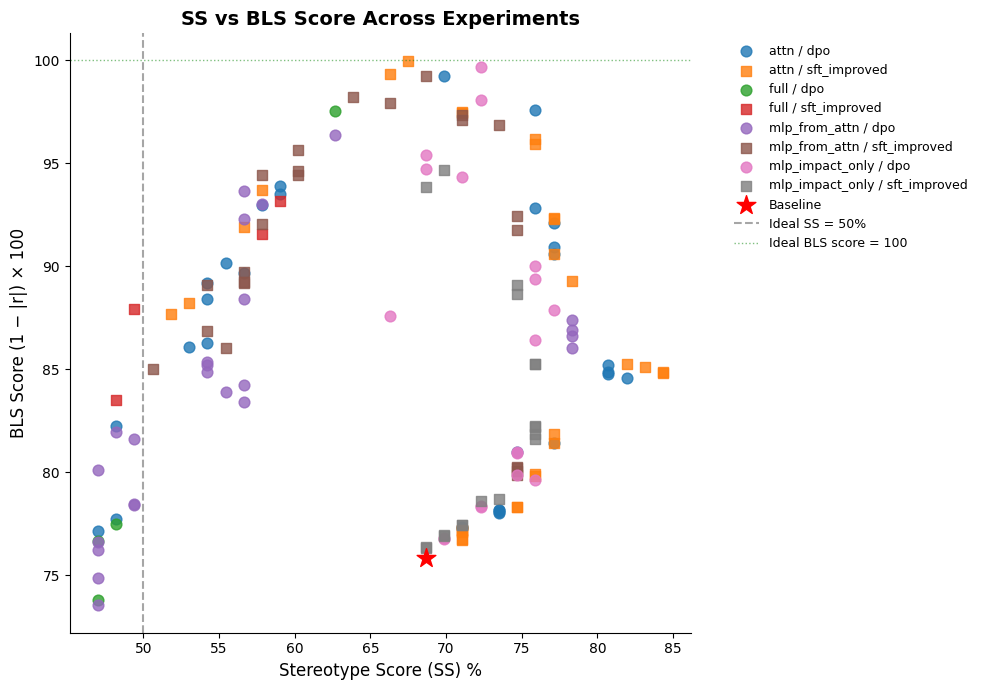

In [42]:
ft_df = metrics_df[metrics_df["loss_type"] != "none"].copy()

markers_map = {"dpo": "o", "sft_improved": "s"}
fig, ax = plt.subplots(figsize=(10, 7))

for exp_type in ft_df["experiment_type"].unique():
    for loss_type in ft_df["loss_type"].unique():
        subset = ft_df[(ft_df["experiment_type"] == exp_type) & (ft_df["loss_type"] == loss_type)]
        if subset.empty:
            continue
        ax.scatter(
            subset["SS"], subset["BLS_score"],
            label=f"{exp_type} / {loss_type}",
            marker=markers_map.get(loss_type, "^"),
            s=60, alpha=0.8,
        )

bl = metrics_df[metrics_df["loss_type"] == "none"]
if not bl.empty:
    ax.scatter(bl["SS"], bl["BLS_score"],
               marker="*", s=200, color="red", zorder=5, label="Baseline")

ax.axvline(x=50, color="gray", linestyle="--", linewidth=1.5, alpha=0.7, label="Ideal SS = 50%")
ax.axhline(y=100, color="green", linestyle=":", linewidth=1, alpha=0.5, label="Ideal BLS score = 100")
ax.set_xlabel("Stereotype Score (SS) %", fontsize=12)
ax.set_ylabel("BLS Score (1 − |r|) × 100", fontsize=12)
ax.set_title("SS vs BLS Score Across Experiments", fontweight="bold", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_ss_vs_bls_score.pdf")
plt.show()

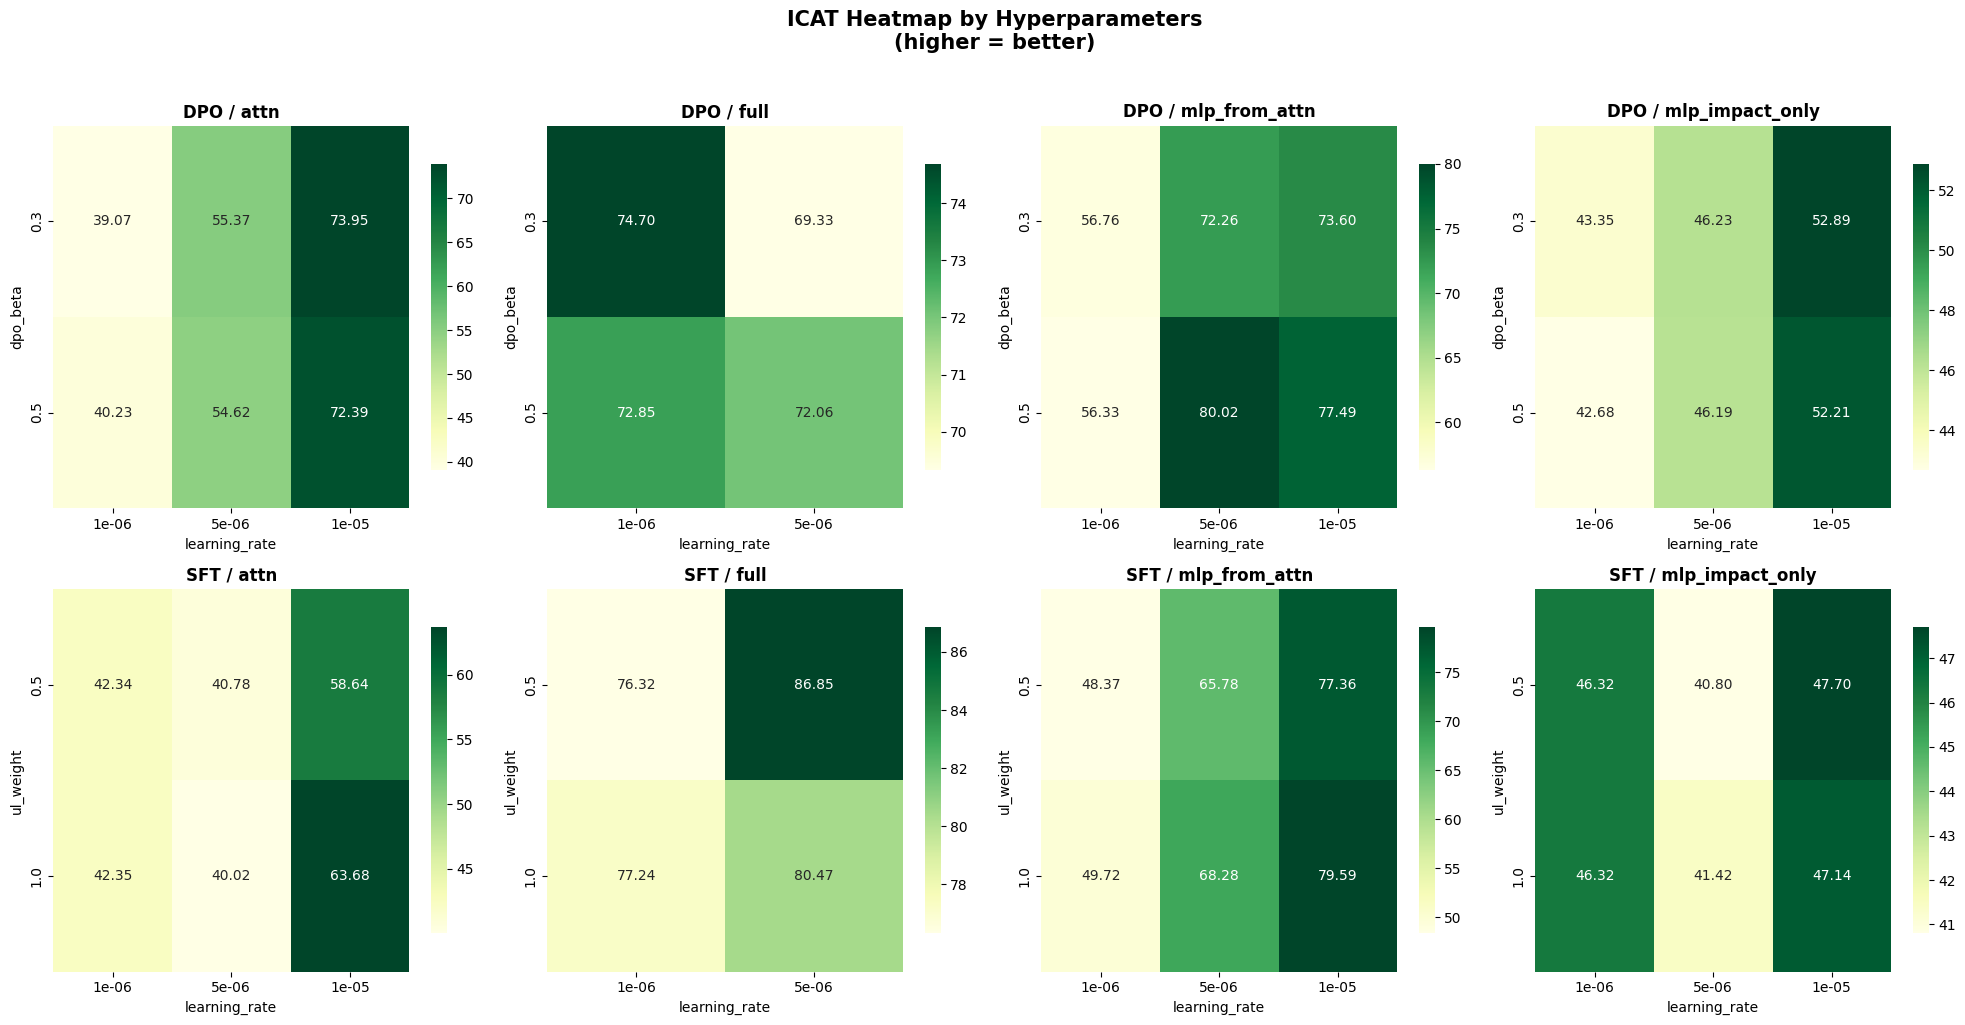

In [35]:
dpo_df = ft_df[ft_df["loss_type"] == "dpo"].copy()
sft_df = ft_df[ft_df["loss_type"] == "sft_improved"].copy()

exp_types = sorted(ft_df["experiment_type"].unique())
n_exp = len(exp_types)

fig, axes = plt.subplots(2, max(n_exp, 1), figsize=(5 * max(n_exp, 1), 10), squeeze=False)
fig.suptitle("ICAT Heatmap by Hyperparameters\n(higher = better)",
             fontweight="bold", fontsize=15, y=1.02)

for col_idx, exp_type in enumerate(exp_types):
    sub = dpo_df[dpo_df["experiment_type"] == exp_type]
    if not sub.empty:
        pivot = sub.pivot_table(index="dpo_beta", columns="learning_rate",
                                values="ICAT", aggfunc="mean")
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGn", ax=axes[0, col_idx],
                    cbar_kws={"shrink": 0.8})
        axes[0, col_idx].set_title(f"DPO / {exp_type}", fontweight="bold")
        axes[0, col_idx].set_ylabel("dpo_beta")
        axes[0, col_idx].set_xlabel("learning_rate")
    else:
        axes[0, col_idx].set_visible(False)

    sub = sft_df[sft_df["experiment_type"] == exp_type]
    if not sub.empty:
        pivot = sub.pivot_table(index="ul_weight", columns="learning_rate",
                                values="ICAT", aggfunc="mean")
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGn", ax=axes[1, col_idx],
                    cbar_kws={"shrink": 0.8})
        axes[1, col_idx].set_title(f"SFT / {exp_type}", fontweight="bold")
        axes[1, col_idx].set_ylabel("ul_weight")
        axes[1, col_idx].set_xlabel("learning_rate")
    else:
        axes[1, col_idx].set_visible(False)

plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_icat_heatmap.pdf")
plt.show()

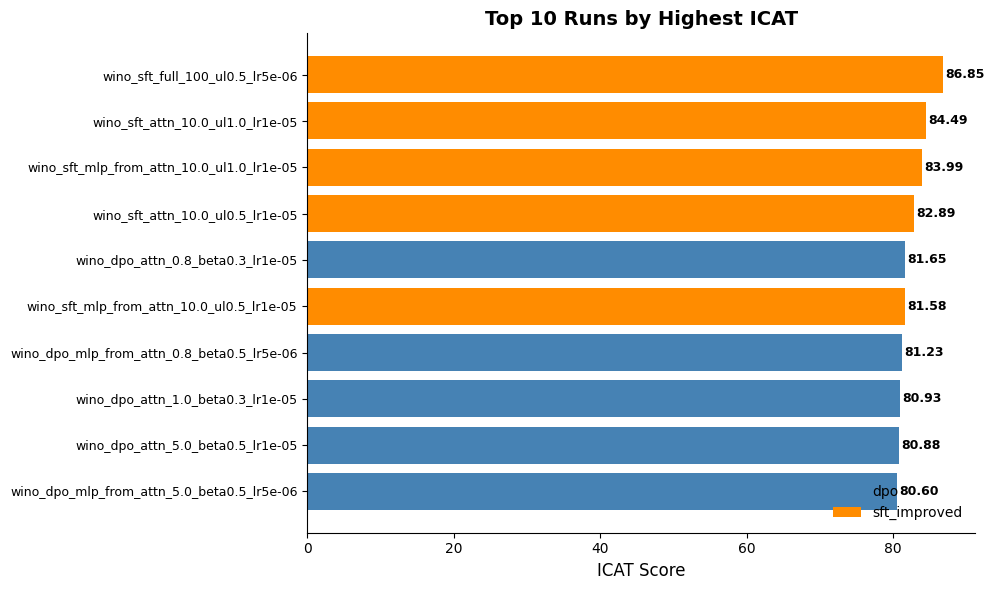

In [36]:
top_icat = metrics_df.nlargest(10, "ICAT").reset_index(drop=True)

color_map = {"dpo": "steelblue", "sft_improved": "darkorange", "none": "gray"}
colors = [color_map.get(lt, "gray") for lt in top_icat["loss_type"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_icat)), top_icat["ICAT"], color=colors)
ax.set_yticks(range(len(top_icat)))
ax.set_yticklabels(top_icat["run_id"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("ICAT Score", fontsize=12)
ax.set_title("Top 10 Runs by Highest ICAT", fontweight="bold", fontsize=14)

for i, val in enumerate(top_icat["ICAT"]):
    ax.text(val + 0.3, i, f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items() if l in top_icat["loss_type"].values]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_top10_icat.pdf")
plt.show()

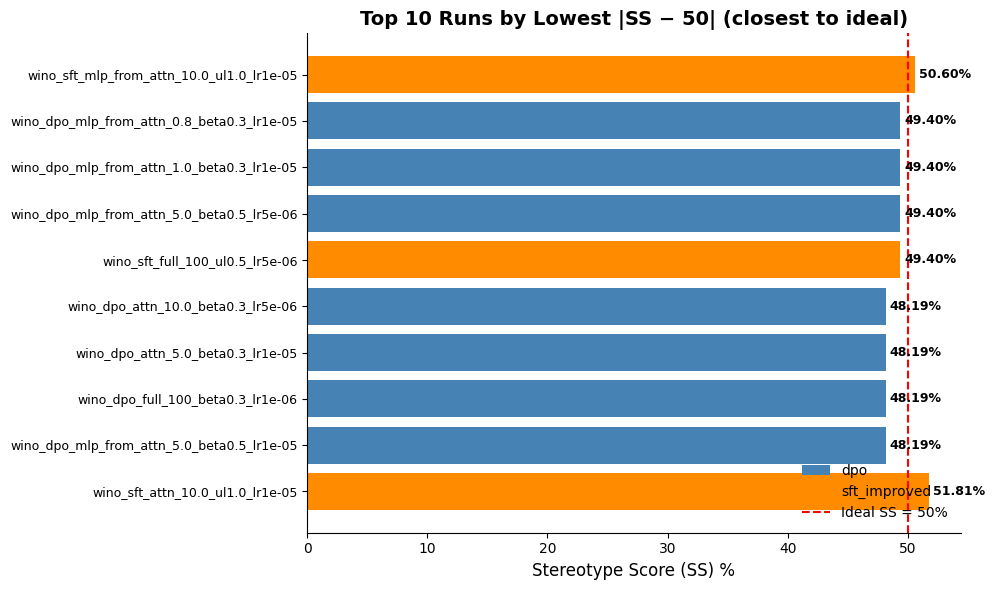

In [37]:
top_ss = metrics_df.nsmallest(10, "SS_deviation").reset_index(drop=True)

colors = [color_map.get(lt, "gray") for lt in top_ss["loss_type"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_ss)), top_ss["SS"], color=colors)
ax.axvline(x=50, color="red", linestyle="--", linewidth=1.5, label="Ideal SS = 50%")
ax.set_yticks(range(len(top_ss)))
ax.set_yticklabels(top_ss["run_id"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Stereotype Score (SS) %", fontsize=12)
ax.set_title("Top 10 Runs by Lowest |SS − 50| (closest to ideal)", fontweight="bold", fontsize=14)

for i, val in enumerate(top_ss["SS"]):
    ax.text(val + 0.3, i, f"{val:.2f}%", va="center", fontsize=9, fontweight="bold")

legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items() if l in top_ss["loss_type"].values]
legend_elements.append(plt.Line2D([0], [0], color="red", linestyle="--", label="Ideal SS = 50%"))
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_top10_ss_deviation.pdf")
plt.show()

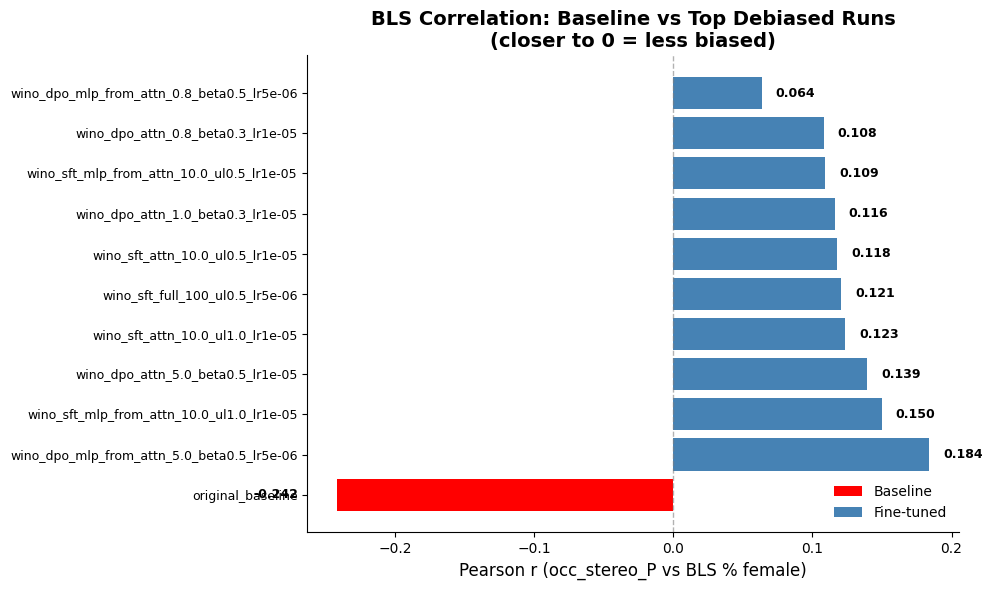

In [38]:
top_n = 10
top_bls = metrics_df.nlargest(top_n, "ICAT")[["run_id", "loss_type", "BLS_r"]].copy()
baseline_row = metrics_df[metrics_df["loss_type"] == "none"][["run_id", "loss_type", "BLS_r"]]
bls_df = pd.concat([baseline_row, top_bls[top_bls["loss_type"] != "none"]]).drop_duplicates()
bls_df["abs_bls_r"] = bls_df["BLS_r"].abs()
bls_df = bls_df.sort_values("abs_bls_r").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red" if rid == "original_baseline" else "steelblue" for rid in bls_df["run_id"]]
ax.barh(range(len(bls_df)), bls_df["BLS_r"], color=colors)
ax.set_yticks(range(len(bls_df)))
ax.set_yticklabels(bls_df["run_id"], fontsize=9)
ax.invert_yaxis()
ax.axvline(x=0, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Ideal r = 0")
ax.set_xlabel("Pearson r (occ_stereo_P vs BLS % female)", fontsize=12)
ax.set_title("BLS Correlation: Baseline vs Top Debiased Runs\n(closer to 0 = less biased)",
             fontweight="bold", fontsize=14)

for i, val in enumerate(bls_df["BLS_r"]):
    ax.text(val + 0.01 if val >= 0 else val - 0.06, i, f"{val:.3f}",
            va="center", fontsize=9, fontweight="bold")

legend_elements = [
    Patch(facecolor="red", label="Baseline"),
    Patch(facecolor="steelblue", label="Fine-tuned"),
]
ax.legend(handles=legend_elements, frameon=False, loc="lower right")

sns.despine()
plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_bls_correlation.pdf")
plt.show()

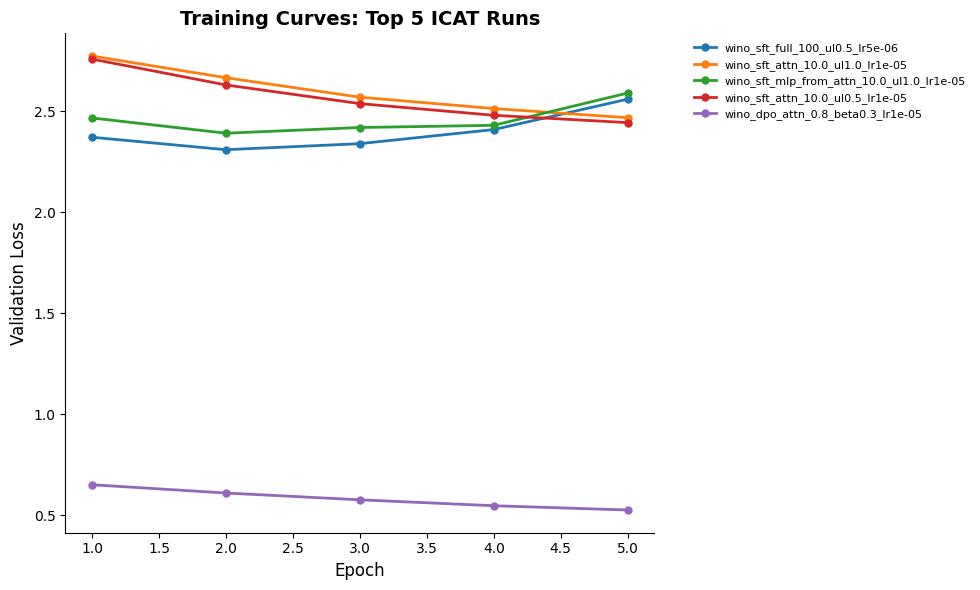

In [39]:
top5_icat_ids = metrics_df[metrics_df["loss_type"] != "none"].nlargest(5, "ICAT")["run_id"].tolist()

fig, ax = plt.subplots(figsize=(10, 6))

for rid in top5_icat_ids:
    meta_row = runs_metadata_df[runs_metadata_df["run_id"] == rid].iloc[0]
    epoch_list = meta_row["epochs"]
    if not epoch_list:
        continue
    epochs = [e["epoch"] for e in epoch_list]
    val_losses = [e["val_loss"] for e in epoch_list]
    ax.plot(epochs, val_losses, marker="o", linewidth=2, markersize=5, label=rid)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Training Curves: Top 5 ICAT Runs", fontweight="bold", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()
s3_utils.save_plot(fig, "outputs/gpt2-xl/winogender/plots/ft_training_curves_top5.pdf")
plt.show()

In [12]:
N_DLA_RUNS = 5
N_DLA_OCCS = 3

dla_run_ids = metrics_df[metrics_df["loss_type"] != "none"].nlargest(N_DLA_RUNS, "ICAT")["run_id"].tolist()

for rid in dla_run_ids:
    if rid not in loaded_runs:
        continue
    print(f"\n{'='*60}\nDetailed DLA plots for: {rid}\n{'='*60}")

    run_data = loaded_runs[rid]
    prob_df = run_data["prob"]
    impact_df = run_data["impact"]
    bias_df = run_data["bias_df"]

    pronoun_occ_df = prob_df[prob_df["Sentence_Role"] == "occupation"].copy()

    top_biased = bias_df.reindex(
        bias_df["diff_stereo"].abs().sort_values(ascending=False).index
    ).head(N_DLA_OCCS)

    for _, row in top_biased.iterrows():
        generate_dla_plot(
            row["occupation"], impact_df, pronoun_occ_df, row,
            save_prefix=f"ft_{rid}_",
        )

    print(f"Done for {rid}.")

del prob_df, impact_df, bias_df, pronoun_occ_df
gc.collect()
print("\nAll DLA plots generated.")


Detailed DLA plots for: dpo_attn_0.8_beta0.3_lr1e-05
Done for dpo_attn_0.8_beta0.3_lr1e-05.

Detailed DLA plots for: dpo_attn_1.0_beta0.3_lr1e-05
Done for dpo_attn_1.0_beta0.3_lr1e-05.

Detailed DLA plots for: dpo_attn_5.0_beta0.3_lr1e-05
Done for dpo_attn_5.0_beta0.3_lr1e-05.

Detailed DLA plots for: dpo_attn_1.0_beta0.5_lr1e-05
Done for dpo_attn_1.0_beta0.5_lr1e-05.

Detailed DLA plots for: dpo_attn_5.0_beta0.3_lr5e-06
Done for dpo_attn_5.0_beta0.3_lr5e-06.
